Name : Nisha Yuvraj Pragane | DIV:SEDA | Roll no :13 | PRN : 1252090013 | BAQTCH :B1

 Assignment 5: Predict the price of the Uber ride from a given pickup point to the agreed drop-off location.
Perform following tasks: 1. Pre-process the dataset. 2. Identify outliers. 3. Check the
correlation. 4. Implement linear regression and ridge, Lasso regression models. 5. Evaluate
the models and compare their respective scores like R2, RMSE, etc. Dataset link:
https://www.kaggle.com/datasets/yasserh/uber-fares-dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


Load Dataset

In [ ]:
df = pd.read_csv("uber.csv")
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1.0
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1.0
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1.0
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3.0
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5.0


Basic info

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35725 entries, 0 to 35724
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         35725 non-null  int64  
 1   key                35725 non-null  object 
 2   fare_amount        35725 non-null  float64
 3   pickup_datetime    35725 non-null  object 
 4   pickup_longitude   35724 non-null  float64
 5   pickup_latitude    35724 non-null  float64
 6   dropoff_longitude  35724 non-null  float64
 7   dropoff_latitude   35724 non-null  float64
 8   passenger_count    35724 non-null  float64
dtypes: float64(6), int64(1), object(2)
memory usage: 2.5+ MB


,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,3.572500e+04,35725.000000,35724.000000,35724.000000,35724.000000,35724.000000,35724.000000
mean,2.765762e+07,11.394681,-72.561212,39.942645,-72.572503,39.943957,1.677024
std,1.604217e+07,10.085005,10.911110,6.047059,10.852786,6.043435,1.294493
min,4.800000e+01,0.000000,-748.016667,-74.015515,-737.916665,-74.008745,0.000000
25%,1.367902e+07,6.000000,-73.992033,40.734753,-73.991475,40.733846,1.000000
50%,2.757853e+07,8.500000,-73.981821,40.752563,-73.980170,40.752855,1.000000
75%,4.151460e+07,12.900000,-73.967196,40.767152,-73.963545,40.768076,2.000000
max,5.542169e+07,350.000000,40.774042,45.031653,40.828377,45.031598,6.000000


Data Preprocessing

In [ ]:
df.drop(columns=['key'], inplace=True)

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
fare_amount,0
pickup_datetime,0
pickup_longitude,1
pickup_latitude,1
dropoff_longitude,1
dropoff_latitude,1
passenger_count,1


In [ ]:
df.dropna(inplace=True)

Convert Pickup dateTime

In [ ]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['hour'] = df['pickup_datetime'].dt.hour
df['day'] = df['pickup_datetime'].dt.day
df['month'] = df['pickup_datetime'].dt.month
df['weekday'] = df['pickup_datetime'].dt.weekday
df.drop(columns=['pickup_datetime'], inplace=True)

Remove Invalid Coordinates

In [ ]:
df = df[
    (df['fare_amount'] > 0) &
    (df['pickup_latitude'].between(-90, 90)) &
    (df['pickup_longitude'].between(-180, 180)) &
    (df['dropoff_latitude'].between(-90, 90)) &
    (df['dropoff_longitude'].between(-180, 180))]

Outlier Detection

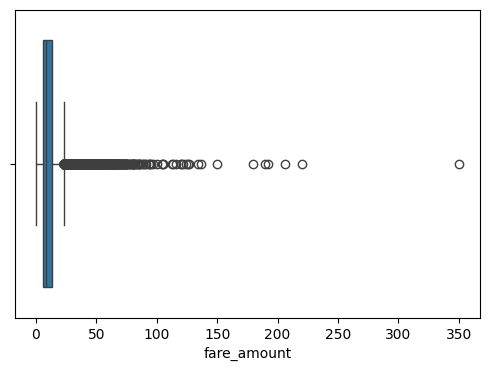

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['fare_amount'])
plt.show()

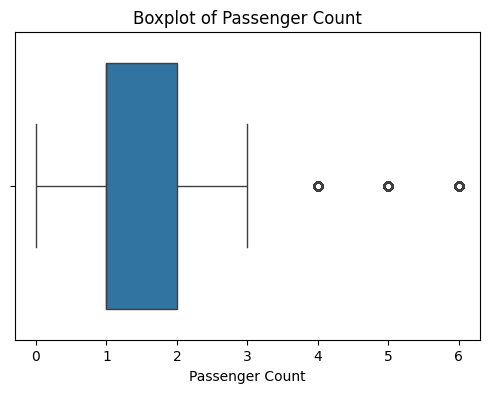

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['passenger_count'])
plt.title("Boxplot of Passenger Count")
plt.xlabel("Passenger Count")
plt.show()

Check Correlation


In [ ]:
df.corr()

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,weekday
Unnamed: 0,1.000000,0.004087,0.001976,-0.001319,0.002842,-0.001030,0.008588,0.001319,0.001429,0.006286,-0.006678
fare_amount,0.004087,1.000000,0.029128,-0.028300,0.028971,-0.028348,0.012631,-0.005083,0.005072,0.026608,0.006835
pickup_longitude,0.001976,0.029128,1.000000,-0.978463,0.950938,-0.937102,0.003077,-0.003885,0.008175,-0.013404,-0.009954
pickup_latitude,-0.001319,-0.028300,-0.978463,1.000000,-0.939256,0.959943,-0.005112,0.005694,-0.011882,0.013335,0.007410
dropoff_longitude,0.002842,0.028971,0.950938,-0.939256,1.000000,-0.980667,0.003888,-0.003115,0.006532,-0.011702,-0.010106
dropoff_latitude,-0.001030,-0.028348,-0.937102,0.959943,-0.980667,1.000000,-0.006214,0.004507,-0.010220,0.012254,0.006766
passenger_count,0.008588,0.012631,0.003077,-0.005112,0.003888,-0.006214,1.000000,0.015303,0.003689,0.008698,0.029244
hour,0.001319,-0.005083,-0.003885,0.005694,-0.003115,0.004507,0.015303,1.000000,0.005397,-0.004695,-0.092286
day,0.001429,0.005072,0.008175,-0.011882,0.006532,-0.010220,0.003689,0.005397,1.000000,-0.019360,0.003826
month,0.006286,0.026608,-0.013404,0.013335,-0.011702,0.012254,0.008698,-0.004695,-0.019360,1.000000,-0.004353


Scatter Plot


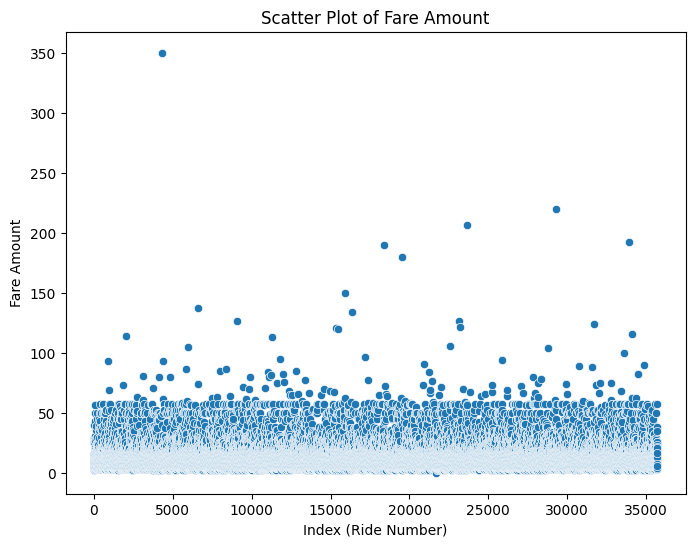

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df.index,
    y=df['fare_amount']
)
plt.title("Scatter Plot of Fare Amount")
plt.xlabel("Index (Ride Number)")
plt.ylabel("Fare Amount")
plt.show()

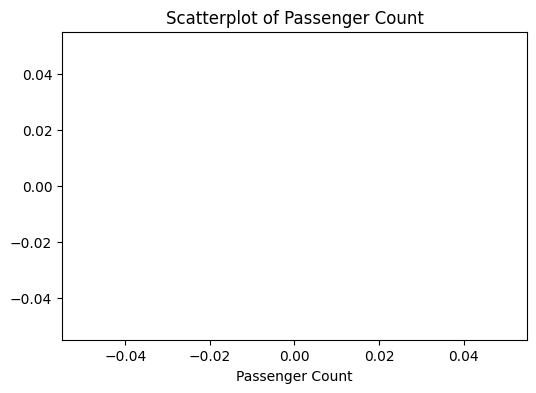

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['passenger_count'])
plt.title("Scatterplot of Passenger Count")
plt.xlabel("Passenger Count")
plt.show()

In [ ]:
Q1 = df['fare_amount'].quantile(0.25)
Q2 = df['fare_amount'].quantile(0.50)
Q3 = df['fare_amount'].quantile(0.75)
IQR = Q3 - Q1
Q1, Q2, Q3, IQR

(np.float64(6.0), np.float64(8.5), np.float64(12.9), np.float64(6.9))

Correlation Analysis

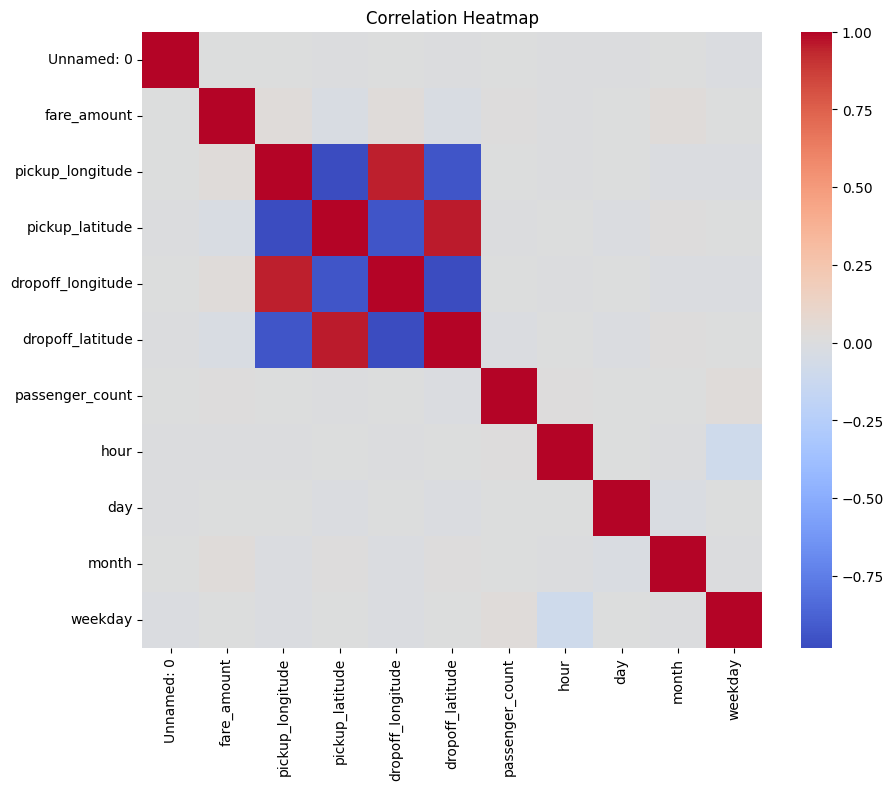

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()

Linear Regression


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
x = np.array([2, 4, 6])
y_observed = np.array([50, 55, 65])

In [ ]:
x_mean = np.mean(x)
y_mean = np.mean(y_observed)

In [ ]:
b1 = np.sum((x - x_mean) * (y_observed - y_mean)) / np.sum((x - x_mean) ** 2)
b0 = y_mean - b1 * x_mean

In [ ]:
y_predicted = b0 + b1 * x
print("b1 (Slope):", b1)
print("b0 (Intercept):", b0)
print("Observed values:", y_observed)
print("Predicted values:", y_predicted)

b1 (Slope): 3.75
b0 (Intercept): 41.666666666666664
Observed values: [50 55 65]
Predicted values: [49.16666667 56.66666667 64.16666667]


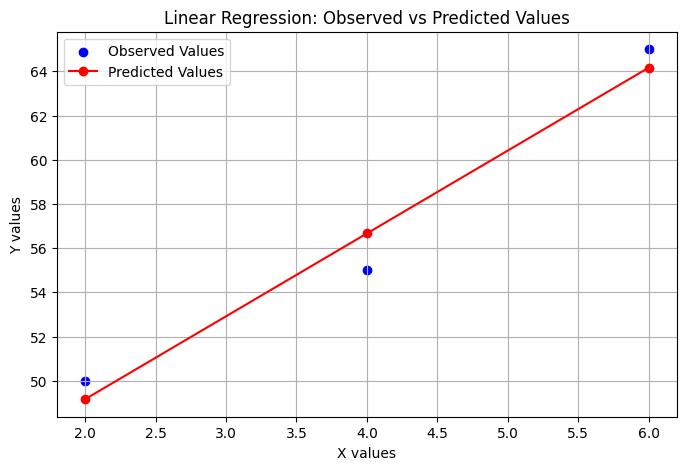

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(x, y_observed, color='blue', label='Observed Values')
plt.plot(x, y_predicted, color='red', marker='o', label='Predicted Values')
plt.xlabel("X values")
plt.ylabel("Y values")
plt.title("Linear Regression: Observed vs Predicted Values")
plt.legend()
plt.grid(True)
plt.show()

Rainfall dataset


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
x = np.array([12.3, 13.7, 14.5, 11.2, 13.2, 14.1, 12.0])
y = np.array([6.25, 8.02, 8.42, 5.27, 7.21, 8.71, 5.68])
x_mean = np.mean(x)
y_mean = np.mean(y)
numerator = np.sum((x - x_mean) * (y - y_mean))
denominator = np.sqrt(np.sum((x - x_mean)**2) * np.sum((y - y_mean)**2))
r = numerator / denominator
print("Linear Correlation Coefficient (r):", r)

Linear Correlation Coefficient (r): 0.9807537506120445


In [ ]:
# Slope
b1 = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean)**2)
# Intercept
b0 = y_mean - b1 * x_mean
print("Slope (b1):", b1)
print("Intercept (b0):", b0)
y_predicted = b0 + b1 * x

Slope (b1): 1.1153669724770643
Intercept (b0): -7.419770642201837


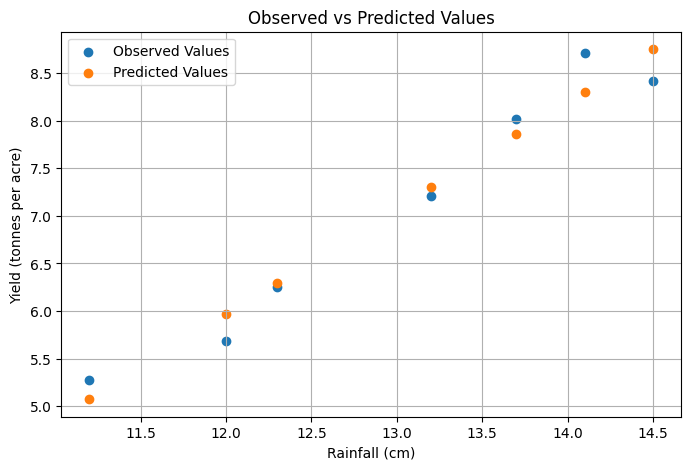

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(x, y, label="Observed Values")
plt.scatter(x, y_predicted, label="Predicted Values")
plt.xlabel("Rainfall (cm)")
plt.ylabel("Yield (tonnes per acre)")
plt.title("Observed vs Predicted Values")
plt.legend()
plt.grid(True)
plt.show()